In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("survey.csv")

df.head(10)

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN
5,2014-08-27 11:31:22,33,Male,United States,TN,NaN,Yes,No,Sometimes,6-25,...,Don't know,No,No,Yes,Yes,No,Maybe,Don't know,No,NaN
6,2014-08-27 11:31:50,35,Female,United States,MI,NaN,Yes,Yes,Sometimes,1-5,...,Somewhat difficult,Maybe,Maybe,Some of them,No,No,No,Don't know,No,NaN
7,2014-08-27 11:32:05,39,M,Canada,NaN,NaN,No,No,Never,1-5,...,Don't know,No,No,No,No,No,No,No,No,NaN
8,2014-08-27 11:32:39,42,Female,United States,IL,NaN,Yes,Yes,Sometimes,100-500,...,Very difficult,Maybe,No,Yes,Yes,No,Maybe,No,No,NaN
9,2014-08-27 11:32:43,23,Male,Canada,NaN,NaN,No,No,Never,26-100,...,Don't know,No,No,Yes,Yes,Maybe,Maybe,Yes,No,NaN


In [5]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64

In [7]:
df = df[(df['Age'] >= 18) & (df['Age'] <= 100)]

In [9]:
df['Gender'] = df['Gender'].str.lower()

In [11]:
def clean_gender(g):
    if 'male' in g or g in ['m','man']:
        return 'Male'
    elif 'female' in g or g in ['f','woman']:
        return 'Female'
    else:
        return 'Other'

df['Gender'] = df['Gender'].fillna('other')
df['Gender'] = df['Gender'].apply(clean_gender)

In [13]:
df.drop(['Timestamp','comments'], axis=1, inplace=True)

In [15]:
df.fillna("Not Answered", inplace=True)

,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37,Male,United States,IL,Not Answered,No,Yes,Often,6-25,No,...,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No
1,44,Male,United States,IN,Not Answered,No,No,Rarely,More than 1000,No,...,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No
2,32,Male,Canada,Not Answered,Not Answered,No,No,Rarely,6-25,No,...,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No
3,31,Male,United Kingdom,Not Answered,Not Answered,Yes,Yes,Often,26-100,No,...,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes
4,31,Male,United States,TX,Not Answered,No,No,Never,100-500,Yes,...,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1254,26,Male,United Kingdom,Not Answered,No,No,Yes,Not Answered,26-100,No,...,Don't know,Somewhat easy,No,No,Some of them,Some of them,No,No,Don't know,No
1255,32,Male,United States,IL,No,Yes,Yes,Often,26-100,Yes,...,Yes,Somewhat difficult,No,No,Some of them,Yes,No,No,Yes,No
1256,34,Male,United States,CA,No,Yes,Yes,Sometimes,More than 1000,No,...,Don't know,Somewhat difficult,Yes,Yes,No,No,No,No,No,No
1257,46,Female,United States,NC,No,No,No,Not Answered,100-500,Yes,...,Don't know,Don't know,Yes,No,No,No,No,No,No,No


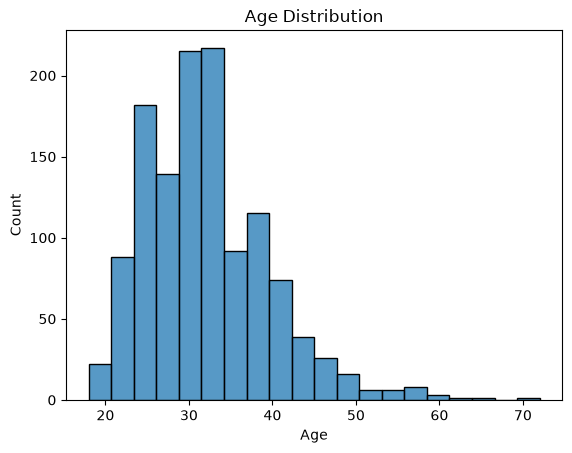

In [17]:
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

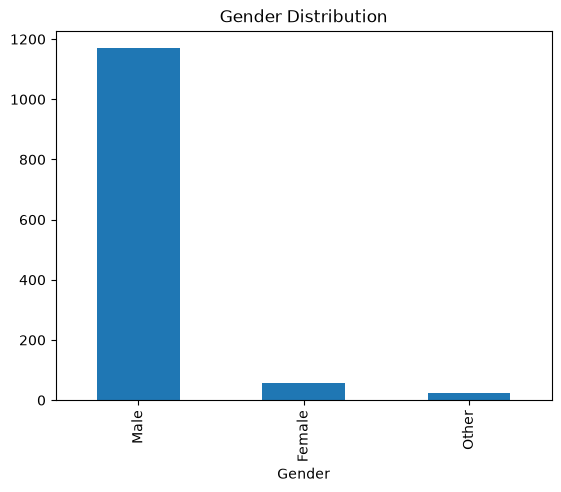

In [19]:
df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.show()

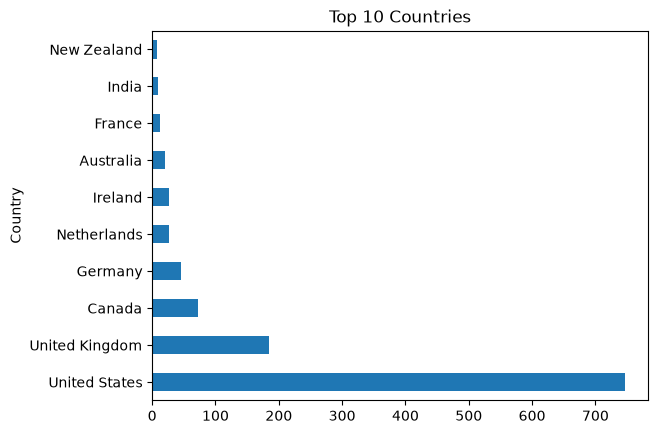

In [21]:
df['Country'].value_counts().head(10).plot(kind='barh')
plt.title("Top 10 Countries")
plt.show()

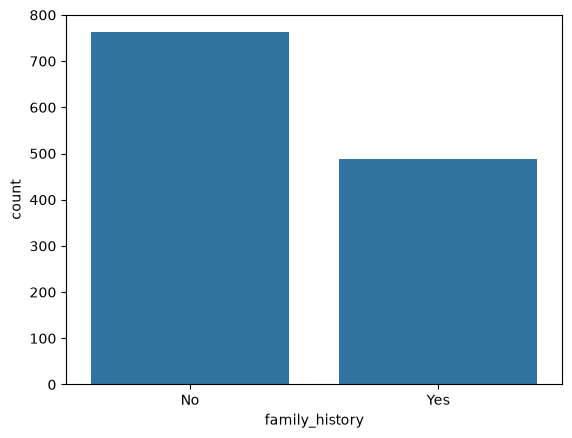

In [23]:
sns.countplot(x='family_history', data=df)
plt.show()

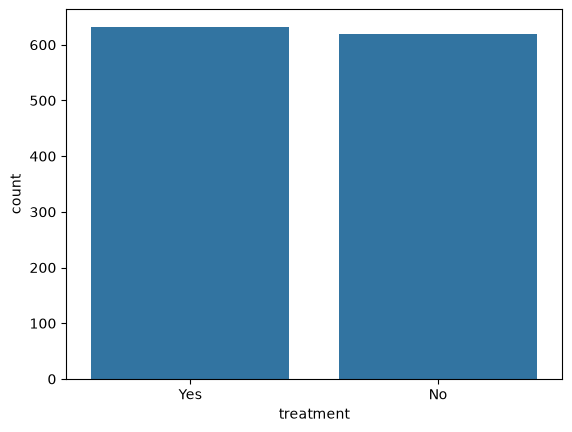

In [25]:
sns.countplot(x='treatment', data=df)
plt.show()

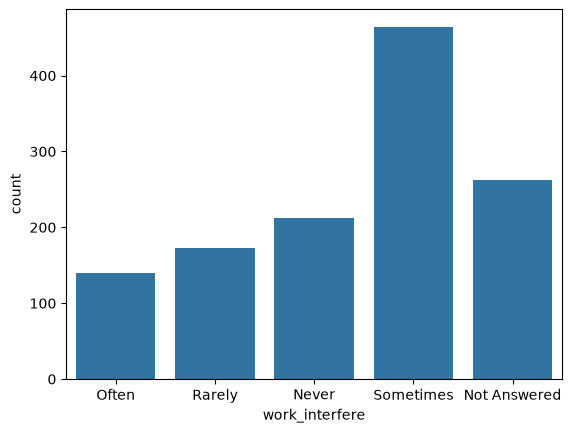

In [27]:
sns.countplot(x='work_interfere', data=df)
plt.show()

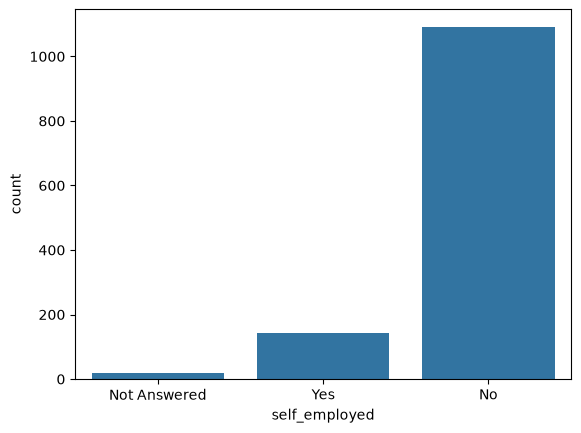

In [29]:
sns.countplot(x='self_employed', data=df)
plt.show()

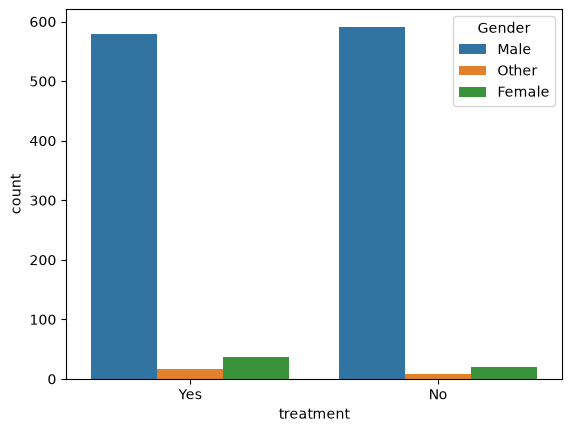

In [31]:
sns.countplot(
    x='treatment',
    hue='Gender',
    data=df
)

plt.show()

In [33]:
pd.crosstab(
    df['Country'],
    df['work_interfere']
).head(10)

work_interfere,Never,Not Answered,Often,Rarely,Sometimes
Country,,,,,
Australia,3,1,5,2,10
Austria,0,2,0,0,1
Belgium,1,2,1,1,1
Bosnia and Herzegovina,0,0,0,1,0
Brazil,1,2,0,2,1
Bulgaria,1,1,0,1,1
Canada,16,9,11,7,29
China,0,0,0,0,1
Colombia,0,0,1,0,1


<Axes: xlabel='no_employees'>

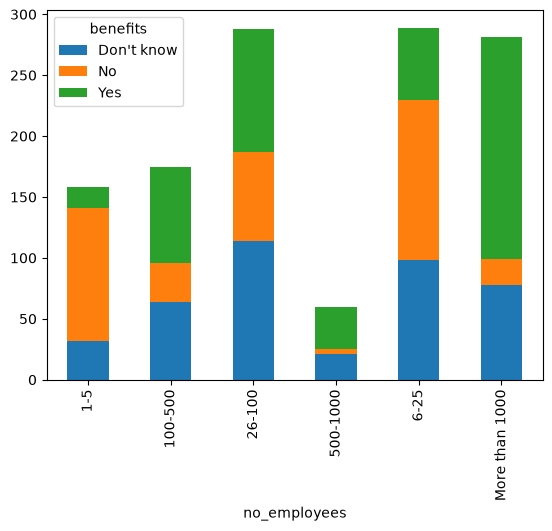

In [37]:
pd.crosstab(
    df['no_employees'],
    df['benefits']
).plot(kind='bar', stacked=True)

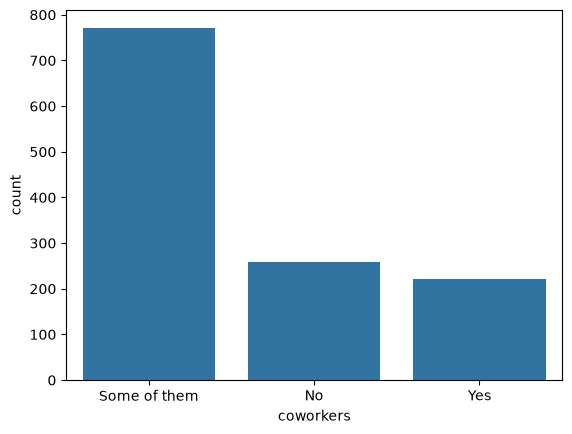

In [39]:
sns.countplot(x='coworkers', data=df)
plt.show()

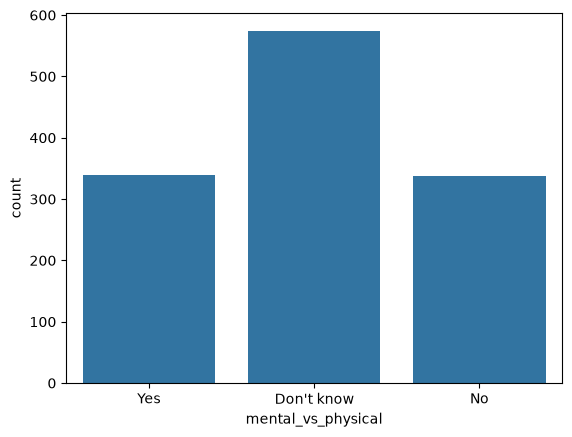

In [41]:
sns.countplot(
    x='mental_vs_physical',
    data=df
)
plt.show()

<Axes: xlabel='state'>

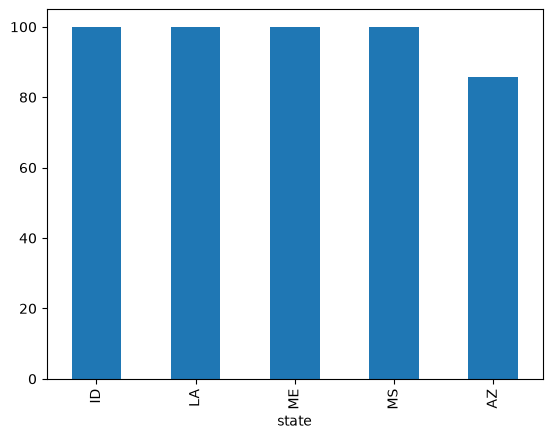

In [45]:
us_df = df[df['Country'] == 'United States']

state_treatment = (
    us_df.groupby('state')['treatment']
    .apply(lambda x: (x == 'Yes').mean()*100)
    .sort_values(ascending=False)
    .head(5)
)

state_treatment.plot(kind='bar')

In [47]:
pd.crosstab(
    df['remote_work'],
    df['treatment'],
    normalize='index'
)

treatment,No,Yes
remote_work,,
No,0.503409,0.496591
Yes,0.474394,0.525606


In [49]:
df_encoded = df.copy()

df_encoded.replace({
    'Yes':1,
    'No':0
}, inplace=True)

,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37,Male,United States,IL,Not Answered,0,1,Often,6-25,0,...,1,Somewhat easy,0,0,Some of them,1,0,Maybe,1,0
1,44,Male,United States,IN,Not Answered,0,0,Rarely,More than 1000,0,...,Don't know,Don't know,Maybe,0,0,0,0,0,Don't know,0
2,32,Male,Canada,Not Answered,Not Answered,0,0,Rarely,6-25,0,...,Don't know,Somewhat difficult,0,0,1,1,1,1,0,0
3,31,Male,United Kingdom,Not Answered,Not Answered,1,1,Often,26-100,0,...,0,Somewhat difficult,1,1,Some of them,0,Maybe,Maybe,0,1
4,31,Male,United States,TX,Not Answered,0,0,Never,100-500,1,...,Don't know,Don't know,0,0,Some of them,1,1,1,Don't know,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1254,26,Male,United Kingdom,Not Answered,0,0,1,Not Answered,26-100,0,...,Don't know,Somewhat easy,0,0,Some of them,Some of them,0,0,Don't know,0
1255,32,Male,United States,IL,0,1,1,Often,26-100,1,...,1,Somewhat difficult,0,0,Some of them,1,0,0,1,0
1256,34,Male,United States,CA,0,1,1,Sometimes,More than 1000,0,...,Don't know,Somewhat difficult,1,1,0,0,0,0,0,0
1257,46,Female,United States,NC,0,0,0,Not Answered,100-500,1,...,Don't know,Don't know,1,0,0,0,0,0,0,0


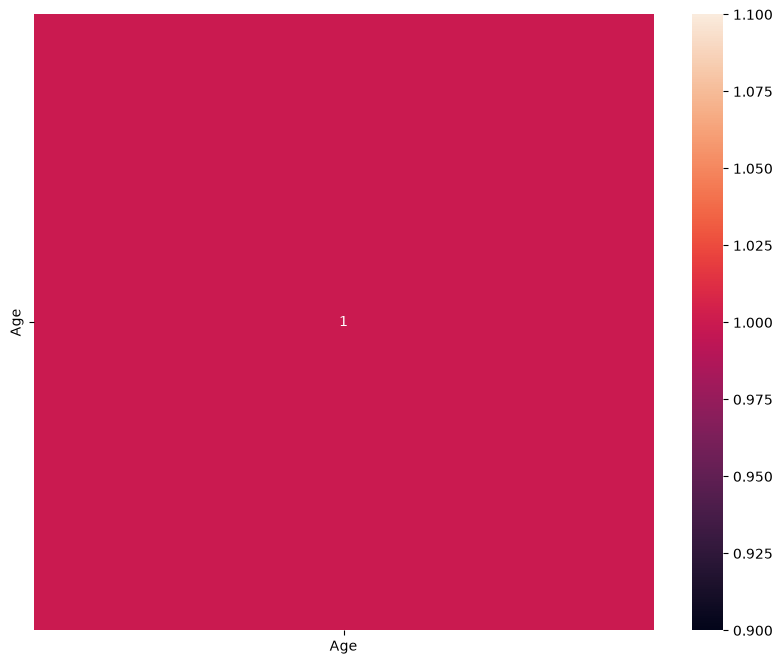

In [51]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df_encoded.select_dtypes(
        include=['number']
    ).corr(),
    annot=True
)

plt.show()

5–7 Key Insights

1. Most respondents who sought treatment also reported a family history of mental illness.

2. Employees in larger companies are more likely to receive mental health benefits.

3. Many respondents are comfortable discussing mental health with coworkers but not during job interviews.

4. Remote workers show different treatment-seeking patterns compared to non-remote workers.

5. Awareness of mental health care options is higher in organizations with wellness programs.

6. Mental health is often perceived as being treated less seriously than physical health.

7. Company size appears to influence access to support resources.

2–3 Recommendations

1. Increase awareness of available mental health care options through regular communication and training.

2. Expand workplace wellness programs focused on mental health support.

3. Strengthen confidentiality and anonymity protections to encourage employees to seek help.

# Mental Health in Tech Survey EDA

## Data Cleaning

## Univariate Analysis

## Bivariate Analysis

## Attitudes Toward Mental Health

## Geographic & Remote Work Insights

## Correlation Analysis

## Key Insights

## Recommendations

## Conclusion

## Conclusion

This exploratory data analysis examined mental health attitudes and experiences among professionals in the technology industry. The analysis identified patterns related to treatment seeking, workplace support, company size, remote work, and perceptions of mental health.

The results suggest that organizational factors such as mental health benefits, wellness programs, and awareness of care options influence employee perceptions and support. Differences were also observed across gender, employer characteristics, and work arrangements.

Organizations can improve employee well-being by expanding mental health resources, increasing awareness programs, and fostering an environment where employees feel comfortable seeking support. Overall, the findings highlight the importance of proactive mental health initiatives within technology workplaces.
